# Interest-rate implied volatility surfaces

This notebook plots **Black–76**, **SABR**, and a **piecewise caplet–style** (LMM-flavored, flat in strike) surface.

The **first** code cell adds the **repository root** to `sys.path` so imports work whether the kernel’s working directory is the repo or `notebooks/`. The **second** cell imports NumPy, Matplotlib, and `helper_module`.

Recommended: from the repo root, `pip install -e .` and use the project venv as the Jupyter kernel; `pip install jupyter` or `pip install -e ".[notebook]"` for the notebook extra.

In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path (notebook cwd may be repo root or notebooks/)
_root = Path.cwd().resolve()
for _base in [_root, *_root.parents]:
    if (_base / "helper_module").is_dir() and (_base / "pyproject.toml").is_file():
        _repo = str(_base)
        if _repo not in sys.path:
            sys.path.insert(0, _repo)
        break
else:
    raise RuntimeError(
        "Could not find project root (folder with helper_module/ and pyproject.toml). "
        "Open the notebook from this repo or run: pip install -e ."
    )

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from helper_module.black76 import black76_price, black76_implied_vol
from helper_module.sabr import sabr_implied_vol_lognormal

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

# macOS often defaults to Arial; it lacks superscript glyphs used by scientific
# notation on colorbars. Prefer DejaVu Sans and render exponents with mathtext.
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"],
        "axes.formatter.use_mathtext": True,
        "mathtext.fontset": "dejavusans",
    }
)
%matplotlib inline

## 1. Black–76 (flat lognormal vol)

Black–76 does not **generate** a smile by itself: quoted **Black vol** $\sigma_B$ is the input. We show a **flat** surface $\sigma_B(K, T) = \text{const}$, then invert prices back to implied vol. That inversion matches $\sigma$ up to **floating-point noise** (~$10^{-11}$). If you plot implied vol with `contourf` using default limits, **matplotlib stretches that tiny noise across the full colormap**, so it looks “striped” even though $\hat\sigma$ is effectively constant. The notebook fixes the color scale and adds a residual plot.

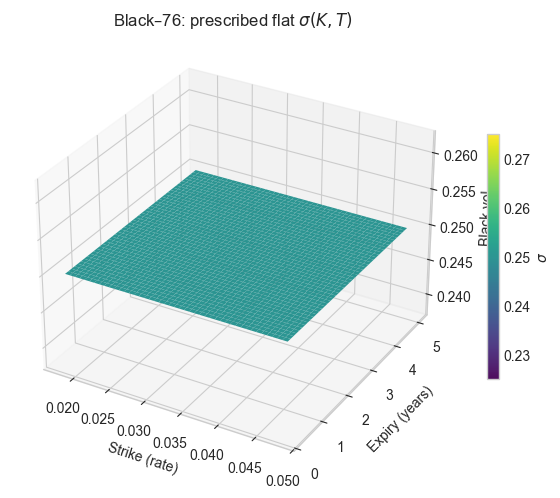

max |implied σ − σ_input| = 3.123e-11


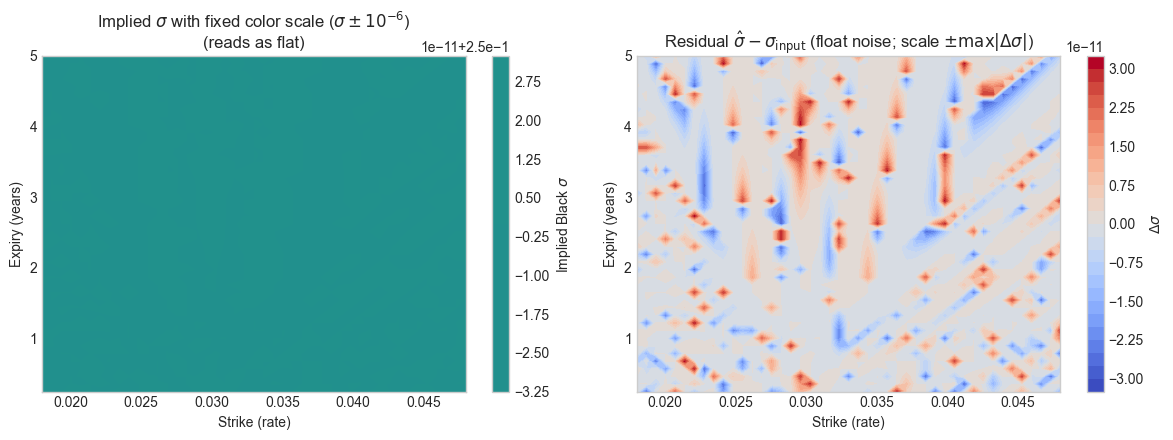

In [8]:
forward = 0.03
sigma_flat = 0.25
# Strikes not too far from forward so implied-vol inversion stays well bracketed
strikes = np.linspace(0.018, 0.048, 45)
expiries = np.linspace(0.25, 5.0, 45)
K, T = np.meshgrid(strikes, expiries)
Z_black = np.full_like(K, sigma_flat, dtype=float)

fig = plt.figure(figsize=(6.5, 5))
ax = fig.add_subplot(1, 1, 1, projection="3d")
surf = ax.plot_surface(K, T, Z_black, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.95)
ax.set_xlabel("Strike (rate)")
ax.set_ylabel("Expiry (years)")
ax.set_zlabel("Black vol")
ax.set_title(r"Black–76: prescribed flat $\sigma(K,T)$")
fig.colorbar(surf, ax=ax, shrink=0.55, label=r"$\sigma$")
plt.tight_layout()
plt.show()

vprice = np.vectorize(black76_price, otypes=[float])
vimplied = np.vectorize(black76_implied_vol, otypes=[float])
px = vprice(forward, K, T, sigma_flat)
iv_grid = vimplied(forward, K, T, px)

# Inversion is exact up to float noise (~1e-11). contourf's default vmin/vmax uses
# data min/max, so that tiny noise fills the whole colormap — fix the scale to σ±ε.
err = iv_grid - sigma_flat
max_abs_err = float(np.max(np.abs(err)))
print(f"max |implied σ − σ_input| = {max_abs_err:.3e}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))
eps = 1e-6
c0 = ax0.contourf(
    K, T, iv_grid, levels=30, cmap="viridis", vmin=sigma_flat - eps, vmax=sigma_flat + eps
)
ax0.set_xlabel("Strike (rate)")
ax0.set_ylabel("Expiry (years)")
ax0.set_title(
    r"Implied $\sigma$ with fixed color scale ($\sigma \pm 10^{-6}$)" + "\n(reads as flat)"
)
plt.colorbar(c0, ax=ax0, label=r"Implied Black $\sigma$")

# Residual σ̂ − σ: symmetric scale so tiny float noise is visible, not blown up
emax = float(np.max(np.abs(err)))
emax = max(emax, 1e-15)
c1 = ax1.contourf(K, T, err, levels=30, cmap="coolwarm", vmin=-emax, vmax=emax)
ax1.set_xlabel("Strike (rate)")
ax1.set_ylabel("Expiry (years)")
ax1.set_title(
    r"Residual $\hat\sigma - \sigma_{\mathrm{input}}$ (float noise; scale $\pm\max|\Delta\sigma|$)"
)
cb1 = plt.colorbar(c1, ax=ax1, label=r"$\Delta\sigma$")
plt.tight_layout()
plt.show()

## 2. SABR smile across strike and expiry

Hagan et al. **lognormal** implied vol $\sigma_B(K, T)$ for fixed forward. Parameters can vary with $T$; here $\alpha(T)$ scales mildly with horizon for a more realistic term structure.

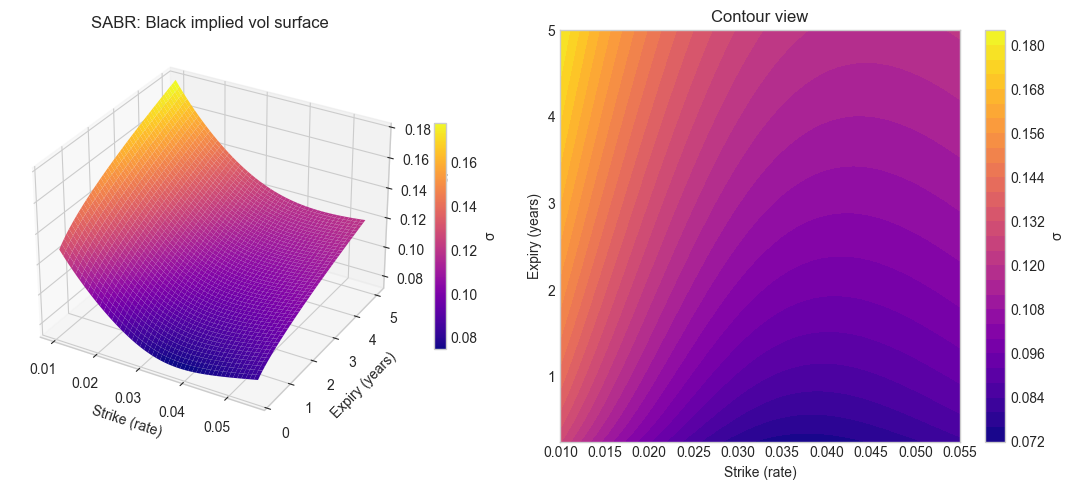

In [4]:
f0 = 0.03
beta, rho, nu = 0.4, -0.25, 0.35

def alpha_of_t(t: float) -> float:
    return 0.015 + 0.006 * np.sqrt(np.maximum(t, 0.05))

strikes_s = np.linspace(0.01, 0.055, 50)
expiries_s = np.linspace(0.25, 5.0, 50)
Ks, Ts = np.meshgrid(strikes_s, expiries_s)
Z_sabr = np.vectorize(lambda k, t: sabr_implied_vol_lognormal(f0, k, t, alpha_of_t(t), beta, rho, nu))(
    Ks, Ts
)

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(Ks, Ts, Z_sabr, cmap=cm.plasma, linewidth=0, antialiased=True)
ax1.set_xlabel("Strike (rate)")
ax1.set_ylabel("Expiry (years)")
ax1.set_zlabel("Black vol")
ax1.set_title("SABR: Black implied vol surface")
fig.colorbar(surf, ax=ax1, shrink=0.55, label="σ")

ax2 = fig.add_subplot(1, 2, 2)
cf = ax2.contourf(Ks, Ts, Z_sabr, levels=28, cmap="plasma")
ax2.set_xlabel("Strike (rate)")
ax2.set_ylabel("Expiry (years)")
ax2.set_title("Contour view")
fig.colorbar(cf, ax=ax2, label="σ")
plt.tight_layout()
plt.show()

## 3. LMM (piecewise caplet vols → surface)

In a discrete **LIBOR market model**, a common setup uses a **constant** $\sigma_i$ per forward. That implies an **ATM caplet** Black vol curve vs fixing time, but **no strike smile** unless you extend the model. Here we plot $\sigma(T_\text{fix}, K)$ as **constant in $K$** within each tenor bucket (a **step** in fixing time), which matches a standard lognormal LMM without stochastic vol.

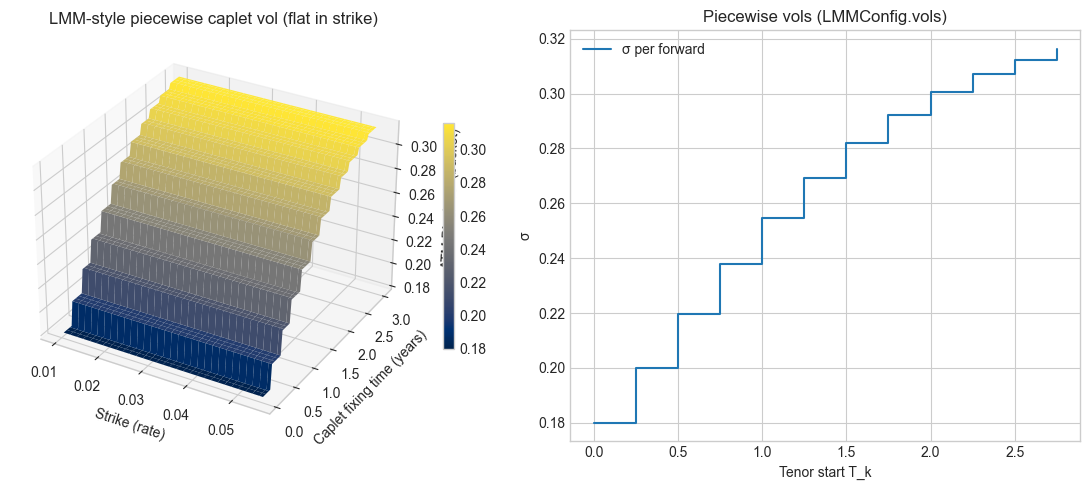

In [5]:
n = 12
tau = np.full(n, 0.25)
t_dates = np.concatenate([[0.0], np.cumsum(tau)])  # T_0..T_n
fixing_times = t_dates[:-1]  # T_k for LIBOR k
vols = np.clip(0.18 + 0.012 * np.arange(n) + 0.03 * np.sin(np.linspace(0, 3, n)), 0.08, None)

strikes_l = np.linspace(0.01, 0.055, 60)
t_axis = np.linspace(0.05, t_dates[-1] - 1e-6, 80)
Klm, Tlm = np.meshgrid(strikes_l, t_axis)

def vol_lmm_piecewise(t: float) -> float:
    idx = min(max(np.searchsorted(t_dates, t, side="right") - 1, 0), n - 1)
    return float(vols[idx])

Z_lmm = np.vectorize(lambda k, t: vol_lmm_piecewise(t))(Klm, Tlm)

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax1.plot_surface(Klm, Tlm, Z_lmm, cmap=cm.cividis, linewidth=0, antialiased=True)
ax1.set_xlabel("Strike (rate)")
ax1.set_ylabel("Caplet fixing time (years)")
ax1.set_zlabel("ATM Black vol (bucket)")
ax1.set_title("LMM-style piecewise caplet vol (flat in strike)")
fig.colorbar(surf, ax=ax1, shrink=0.55)

ax2 = fig.add_subplot(1, 2, 2)
ax2.step(t_dates[:-1], vols, where="post", label="σ per forward")
ax2.set_xlabel("Tenor start T_k")
ax2.set_ylabel("σ")
ax2.set_title("Piecewise vols (per forward bucket)")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

